>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from scenarios_2D import *
from plot_func import *

In [2]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "nP", "sym": "$K$", "int": True}
variable_2 = {"name": "nV", "sym": "$N$", "int": True}
pos = [2,4]

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'-'+variable_2["name"])
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results_2d(dir_name, pos)

# Find variable values that have been tested
vals, scn = find_vals_2d(var_val, variable_1, variable_2)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [4]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [5]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl['scn'] = var_val
conv_repl.head(50)
conv_repl[conv_repl.scn == '60000_250']

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged,scn
408,9,172.161592,41,700.296905,41,True,60000_250
409,63,98.005131,44,533.246557,63,True,60000_250
410,22,121.950281,24,701.024309,24,True,60000_250
411,31,96.403262,44,472.407710,44,True,60000_250
412,55,104.725663,36,724.568004,55,True,60000_250
413,51,107.814800,26,644.554965,51,True,60000_250
414,25,118.060004,16,894.608761,25,True,60000_250
415,46,103.072415,38,611.091319,46,True,60000_250
416,10,146.526048,39,984.771836,39,True,60000_250
417,36,105.986028,39,492.459598,39,True,60000_250


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 7/4 for scenario 15000_1000
Sufficient number of replications: 15/11 for scenario 15000_125
Sufficient number of replications: 5/1 for scenario 15000_1500
Sufficient number of replications: 5/1 for scenario 15000_2000
Sufficient number of replications: 5/3 for scenario 15000_250
Sufficient number of replications: 5/2 for scenario 15000_2500
Sufficient number of replications: 5/4 for scenario 15000_500
Sufficient number of replications: 5/1 for scenario 30000_1000
Sufficient number of replications: 15/13 for scenario 30000_125
Sufficient number of replications: 5/1 for scenario 30000_1500
Sufficient number of replications: 5/1 for scenario 30000_2000
Sufficient number of replications: 7/4 for scenario 30000_250
Sufficient number of replications: 5/1 for scenario 30000_2500
Sufficient number of replications: 5/2 for scenario 30000_500
Sufficient number of replications: 35/13 for scenario 3750_1000
Sufficient number of replications: 35/11 for scenario 37

In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [9]:
eql_scn.dem.loc['45000_125']

inform               14016.700000
requests               415.020000
gets_offer               0.988003
accepts_offer          409.940000
mean_wait              392.473803
corr_mean_wait         408.909724
perc_wait              667.334646
perc_wait_req          505.221009
bike                  9927.540000
car                   2760.160000
pt                     913.980000
nP                   45000.000000
vot_inf                 17.693942
vot_req                 19.227942
std_perc_wait          344.875488
std_exp_wait           284.848420
std_corr_wait          316.503319
std_perc_wait_req      235.180831
cons_surplus           123.509637
pickup_time            369.554021
match_time              22.919782
corr_match_time               NaN
Name: 45000_125, dtype: float64

In [10]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
scenario,,,,,,,,,,,,,,,,,,,,,
15000_1000,1000.0,42.200000,0.0,16.942857,0.0,62.920081,63.158944,62.642934,62.523638,0.473409,...,-464.813143,88.366963,25.843326,16.500351,9.342975,37.371901,3737.190086,6600.140228,10337.330315,0.641065
15000_125,125.0,8.266667,0.0,5.760000,0.0,76.738564,76.510986,76.252301,78.025161,0.578131,...,3.779157,122.132606,44.107445,22.605349,21.502096,86.008382,8600.838249,9042.139711,17642.977960,0.387397
15000_1500,1500.0,59.280000,0.0,19.960000,0.0,57.730259,58.516052,57.914794,58.084586,0.435798,...,-761.759955,81.200300,23.115714,15.183698,7.932016,31.728062,3172.806228,6073.479280,9246.285508,0.678948
15000_2000,2000.0,63.840000,0.0,20.760000,0.0,56.948908,57.666970,56.278860,58.488963,0.429422,...,-829.079030,81.171207,22.682244,15.152055,7.530189,30.120755,3012.075545,6060.822164,9072.897708,0.684969
15000_250,250.0,14.800000,0.0,8.760000,0.0,72.854917,72.997880,72.581886,74.970694,0.548058,...,-54.639533,112.562448,37.591754,20.982020,16.609733,66.438934,6643.893391,8392.808056,15036.701447,0.477892
15000_2500,2500.0,83.880000,0.0,22.880000,0.0,54.383857,55.211103,54.667356,55.549112,0.410658,...,-1233.096888,76.586535,21.037422,14.323269,6.714154,26.856615,2685.661457,5729.307539,8414.968996,0.707814
15000_500,500.0,28.680000,0.0,13.880000,0.0,66.291138,66.620772,67.081467,61.691249,0.498743,...,-321.519977,87.865946,26.174697,16.381054,9.793643,39.174572,3917.457176,6552.421633,10469.878808,0.636463
30000_1000,1000.0,60.720000,0.0,37.040000,0.0,73.544354,74.513045,74.071604,72.685222,0.551105,...,-245.714228,99.252448,26.567226,18.560051,8.007175,32.028701,3202.870066,7424.020451,10626.890517,0.631011
30000_125,125.0,13.653333,0.0,10.840000,0.0,93.209599,93.207720,92.973888,94.984528,0.681311,...,139.086976,144.096380,49.111852,26.754735,22.357117,89.428469,8942.846875,10701.893912,19644.740788,0.317891


In [11]:
eql_scn.plf.head(5)

,plat_profit
15000_1000,491.903132
15000_125,238.856805
15000_1500,535.264320
15000_2000,556.742370
15000_250,327.349110


In [12]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [13]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variable_1, variable_2)
eql_scn.dem = add_scn_vals(eql_scn.dem, variable_1, variable_2)
eql_scn.plf = add_scn_vals(eql_scn.plf, variable_1, variable_2)

# eql_scn.plf[variable_1["name"]] = eql_scn.plf.index.str.split('_').str.get(0).astype(int)
# eql_scn.plf[variable_2["name"]] = eql_scn.plf.index.str.split('_').str.get(1).astype(int)
# eql_scn.index.name = 'scenario'

# # Add missing scenarios to df as nan's
# scn_names = []
# for val_1 in vals_1:
#     for val_2 in vals_2:
#         scn_name = str(val_1)+'_'+str(val_2)
#         scn_names.append(scn_name)
#         if scn_name not in eql_scn.plf.index:
#             eql_scn.plf = eql_scn.plf.append(pd.Series(data={'profit': np.nan,'nP': int(val_1), 'nV': int(val_2)}, name = scn_name), ignore_index=False)

# eql_scn.plf = eql_scn.plf.sort_values(["nP", "nV"])
# eql_scn.plf = eql_scn.plf.set_index(['nP','nV'])
# eql_scn.plf = eql_scn.plf.unstack(level=-1)
# eql_scn.plf.style.background_gradient(axis=None)

In [14]:
# # eql_scn.plf = eql_scn.plf.pivot(index='nP', columns='nV', values='profit')
# # sns.heatmap(data)
# sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values='profit'))
# plt.show()

In [15]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variable_1, variable_2)

C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:204: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:209: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


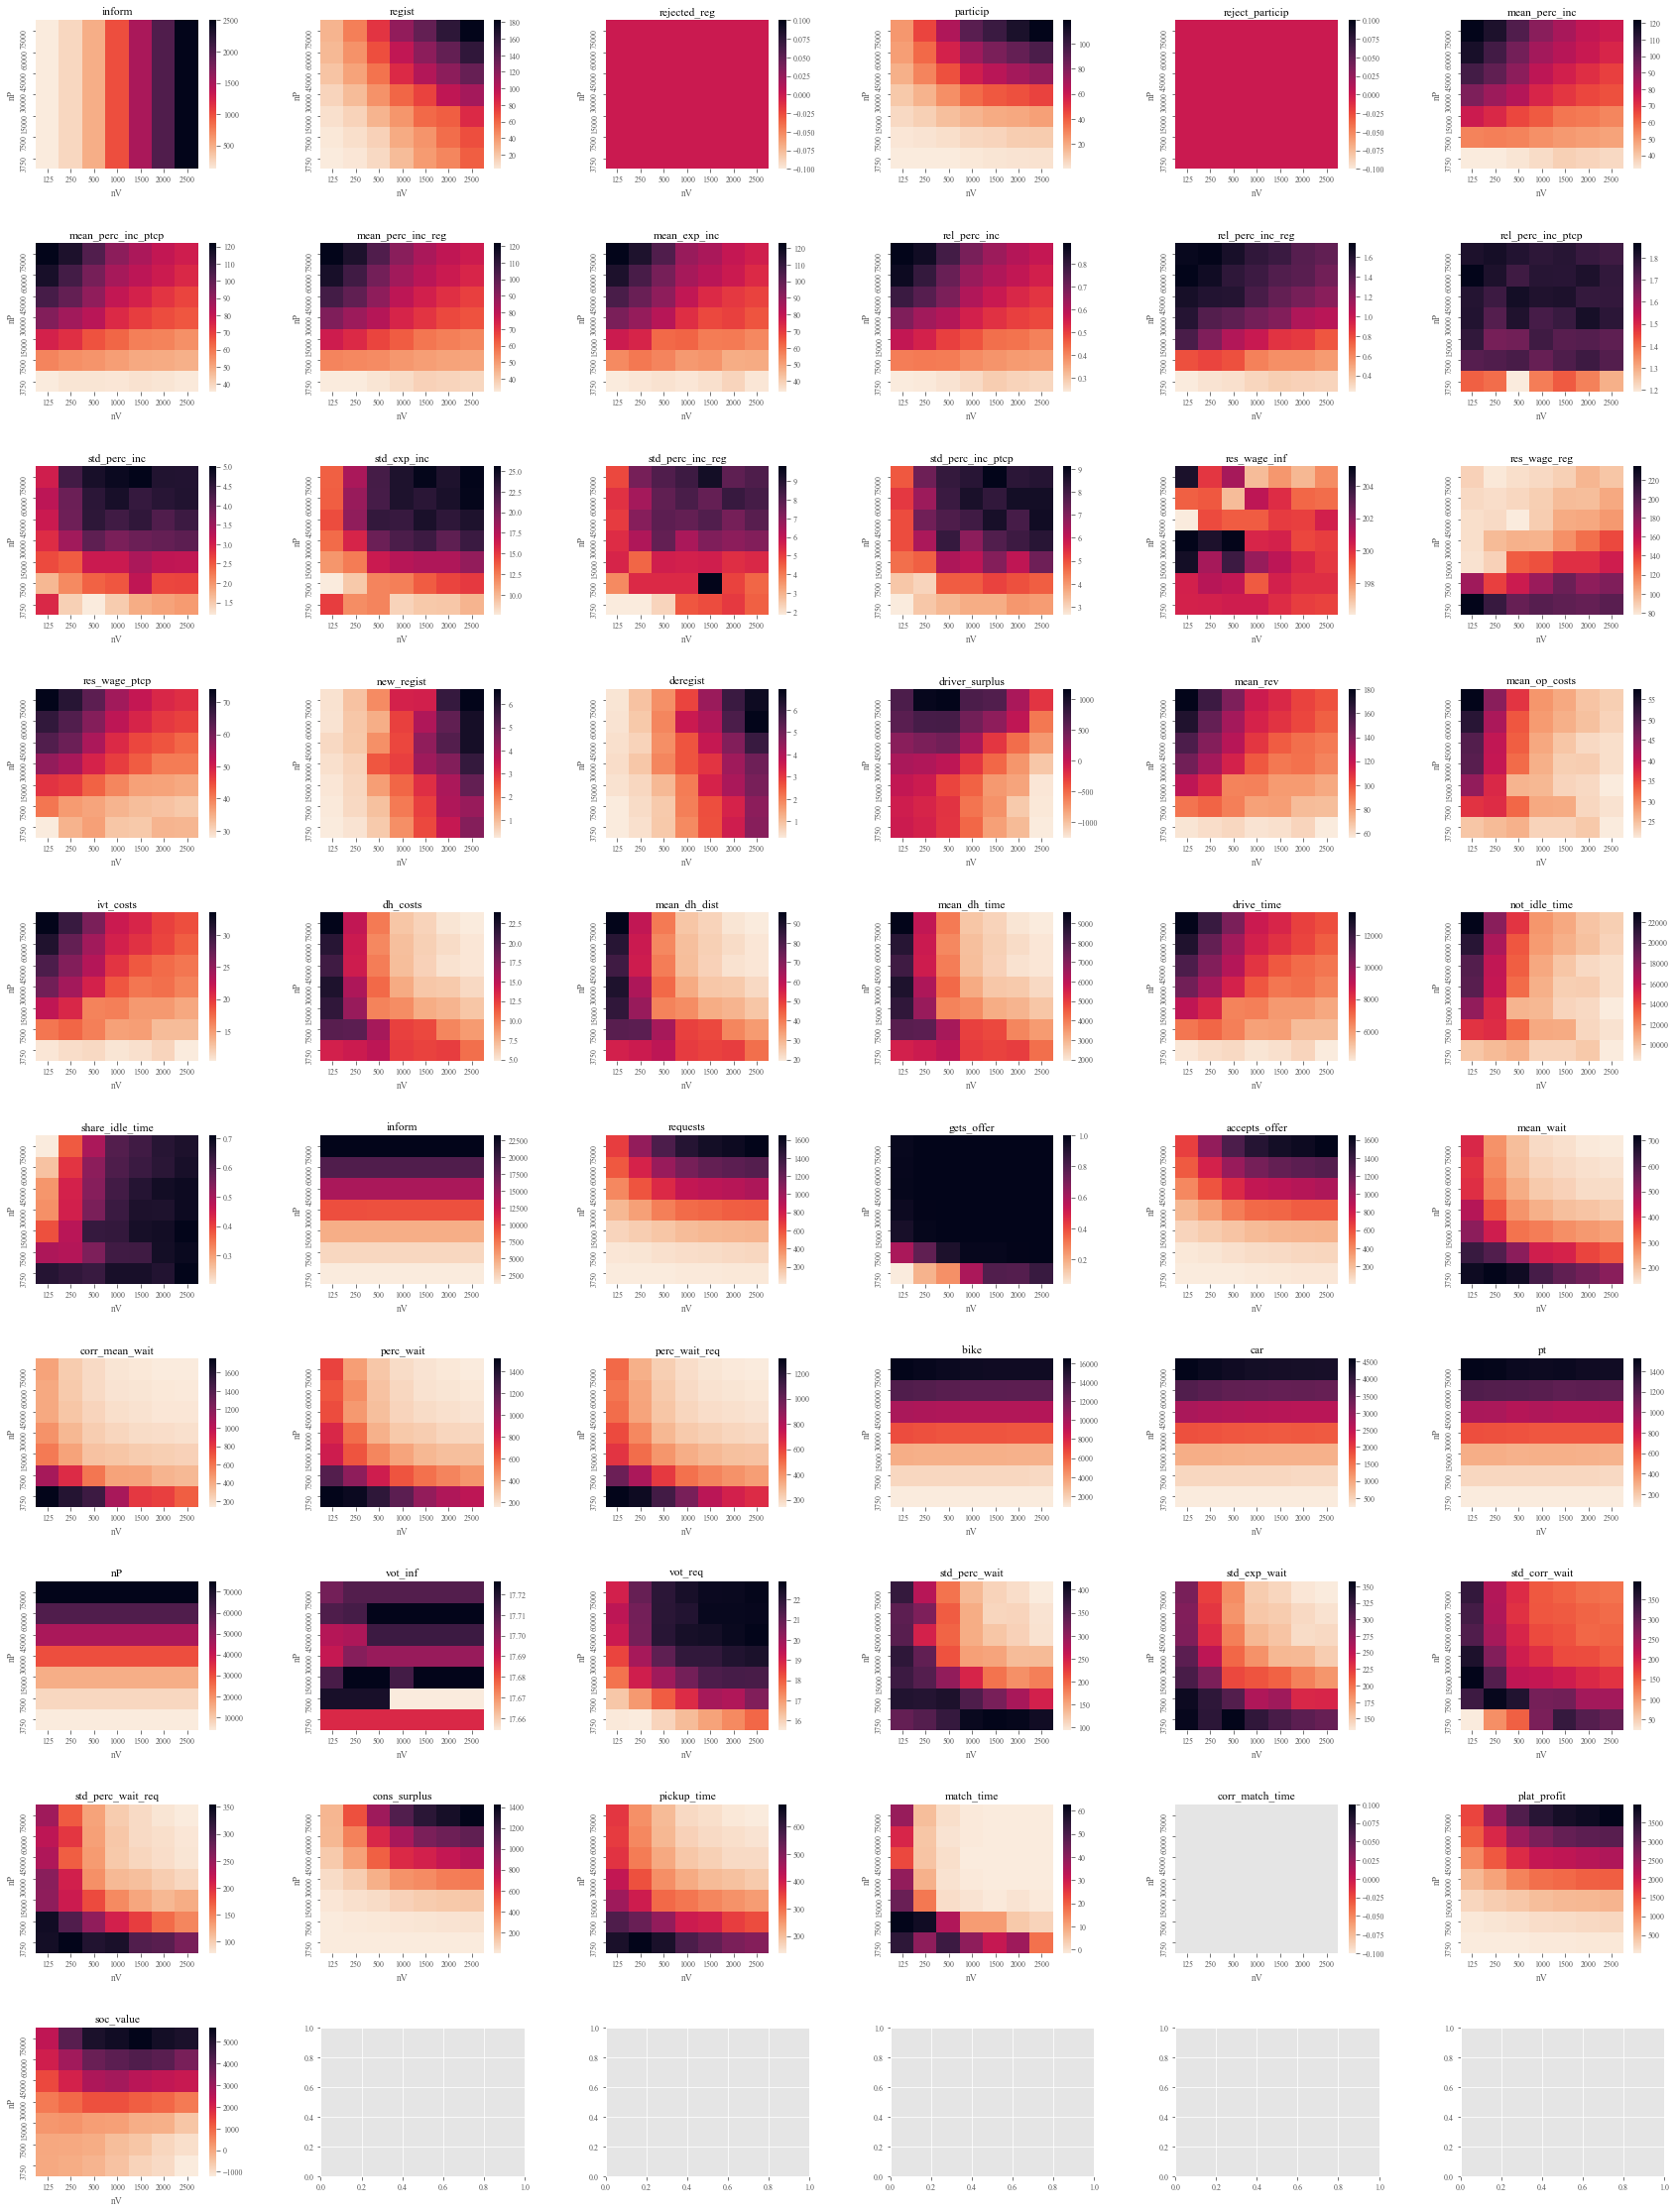

In [16]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(10, 6, figsize = [30,40])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

In [75]:
res.sup[0]

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
day,,,,,,,,,,,,,,,,,,,,,
0,99,18,0,12,0,206.197255,222.367680,193.096636,22.722604,1.000000,...,-2755.740911,32.415469,9.692865,6.161771,3.531094,14.124375,1412.437500,2464.708333,3877.145833,0.865377
1,105,18,0,3,0,162.831213,157.542854,166.477293,45.577500,0.808680,...,-695.896062,68.091750,22.514250,12.881500,9.632750,38.531000,3853.100000,5152.600000,9005.700000,0.687302
2,113,18,0,2,0,135.977607,85.640653,162.745114,92.566875,0.703890,...,-366.848751,147.589875,55.023000,27.547750,27.475250,109.901000,10990.100000,11019.100000,22009.200000,0.235792
3,127,18,0,3,0,125.698100,97.000061,162.899030,60.138333,0.682288,...,-496.453103,96.814875,36.676542,18.347750,18.328792,73.315167,7331.516667,7339.100000,14670.616667,0.490604
4,141,19,0,5,0,109.985088,105.062821,158.438236,38.694750,0.632284,...,-747.518013,61.444125,22.749375,11.454250,11.295125,45.180500,4518.050000,4581.700000,9099.750000,0.684036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1000,39,0,17,0,62.162586,62.565684,63.453708,52.854191,0.467306,...,-542.863867,73.265559,20.411368,13.619471,6.791897,27.167588,2716.758824,5447.788235,8164.547059,0.716509
196,1000,41,0,17,0,60.402553,60.782602,62.380744,58.140735,0.454071,...,-558.203114,80.367485,22.226750,14.947676,7.279074,29.116294,2911.629412,5979.070588,8890.700000,0.691295
197,1000,46,0,19,0,59.923012,60.854233,61.577825,48.970987,0.450271,...,-766.993690,67.737138,18.766151,12.671118,6.095033,24.380132,2438.013158,5068.447368,7506.460526,0.739359


In [73]:
micro.dem.corr_wait_time[0]
micro.sup.keys()

odict_keys(['inform', 'regist', 'ptcp', 'perc_inc', 'exp_inc'])

In [1]:
# requests[0]
# res.sup[0]
# res.dem[0]
params[0]
# res.sup[3]
# res.dem[3]

NameError: name 'params' is not defined

In [19]:
# abc = micro.dem.corr_wait_time[3]
# abc = abc.replace(params[3]['evol']['travellers']['reject_penalty'], np.nan)
# # abc.max()[0] == params[3]['evol']['travellers']['reject_penalty']
# abc = ~abc.isna()
# rs_fare = params[3]['platforms']['base_fare'] + params[3]['platforms']['fare'] * requests[3].dist / 1000
# # rs_fare
# # abc= abc.mul(rs_fare, axis=0)
# # abc = abc.sum(axis=0)
# # abc = abc.div(res.sup[3].particip, axis=0)
# # abc = abc / res.sup[3].particip.to_numpy()
# # abc
# pax_dist = abc.mul(requests[3].dist,axis=0)
# # .sum(axis=0) / 1000
# # pax_dist.sum()
# fare_acc_req = abc.mul(rs_fare, axis=0)
# total_fares = fare_acc_req.sum(axis=0)
# hup = total_fares / res.sup[3].particip.to_numpy()
# res.sup[3]['hup'] = hup.to_numpy()
# res.sup[3]
# # pax_dist = (abc.mul(requests[3].dist,axis=0)).sum(axis=0) / 1000
# # pax_dist
# abc.sum()
# pax_dist.sum() / 1000

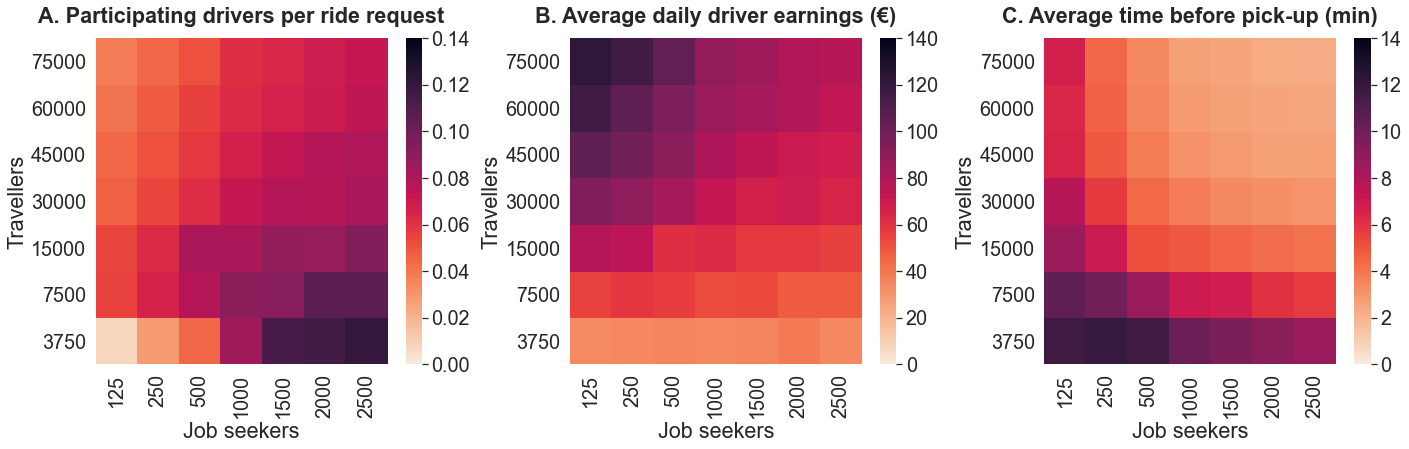

In [20]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 3, figsize = [24,6])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.4, wspace=0.3, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Mode share of ridesourcing')
# axes[1,2].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=140)
axes[1].set_title('B. Average daily driver earnings (\u20ac)', fontweight="bold", pad=15)
axes[1].invert_yaxis()
axes[1].set_xlabel('Job seekers')
axes[1].set_ylabel('Travellers')

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Average driver earnings per satisfied request')
# axes[0,3].invert_yaxis()


# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Satisfied requests per participating driver')
# axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait / 60
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[2], cmap=cmap, vmin=0, vmax=14)
axes[2].set_title('C. Average time before pick-up (min)', fontweight="bold", pad=15)
axes[2].invert_yaxis()
axes[2].set_xlabel('Job seekers')
axes[2].set_ylabel('Travellers')

# res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Share of job seekers with registration')
# axes[0,0].invert_yaxis()

# res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average participation frequency')
# axes[0,1].invert_yaxis()

# res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
# axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[2,1], cmap=cmap)
# axes[2,1].set_title('Service rate')
# axes[2,1].invert_yaxis()


res_proc['driv_per_req'] = eql_scn.sup.particip / eql_scn.dem.requests
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='driv_per_req'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.14)
axes[0].set_title('A. Participating drivers per ride request', fontweight="bold", pad=15)
axes[0].invert_yaxis()
axes[0].set_xlabel('Job seekers')
axes[0].set_ylabel('Travellers')
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps_main.jpg'),dpi=300,bbox_inches='tight')

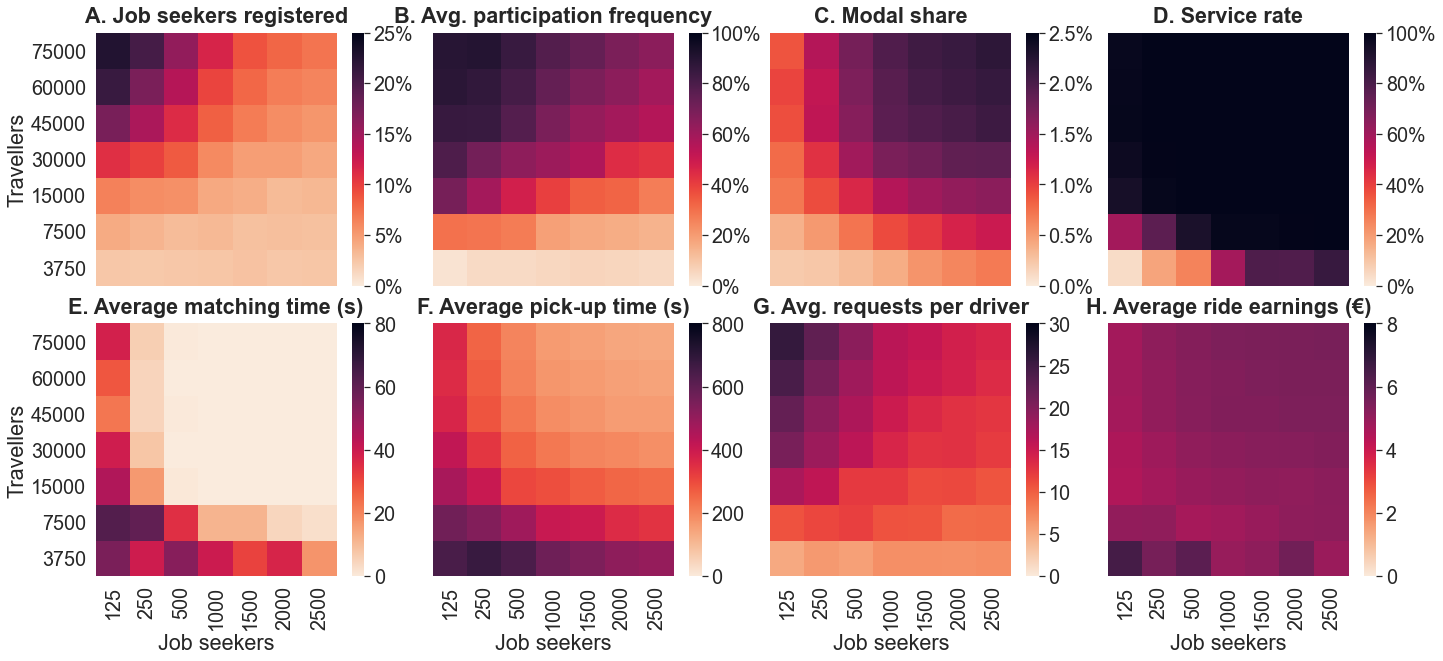

In [61]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(2, 4, figsize = [24,10], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.12, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average daily driver earnings (euro)')
# axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,3], cmap=cmap, vmin=0.0, vmax=8.0)
axes[1,3].set_title('H. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[1,3].invert_yaxis()
axes[1,3].set_xlabel('Job seekers')
axes[1,3].set_ylabel('Travellers')
axes[1,3].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=30)
axes[1,2].set_title('G. Avg. requests per driver', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Average time between request and pick-up')
# axes[1,1].invert_yaxis()

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[0,3], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,3].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,3].set_title('D. Service rate', fontweight="bold", pad=10)
axes[0,3].invert_yaxis()
axes[0,3].set_xlabel('Job seekers')
axes[0,3].set_ylabel('Travellers')
axes[0,3].xaxis.label.set_visible(False)
axes[0,3].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=80)
axes[1,0].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=800)
axes[1,1].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].yaxis.label.set_visible(False)

# res_proc['req_per_driver'] = eql_scn.sup.particip / eql_scn.dem.requests
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_per_driver'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Participating drivers per request')
# axes[2,0].invert_yaxis()
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

# from matplotlib.patches import Rectangle, Polygon, Patch
# array = np.array([[0,0],[7,0],[7,1],[2,1],[2,2],[0,2]])
# axes[1,0].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient strategy')]

# fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

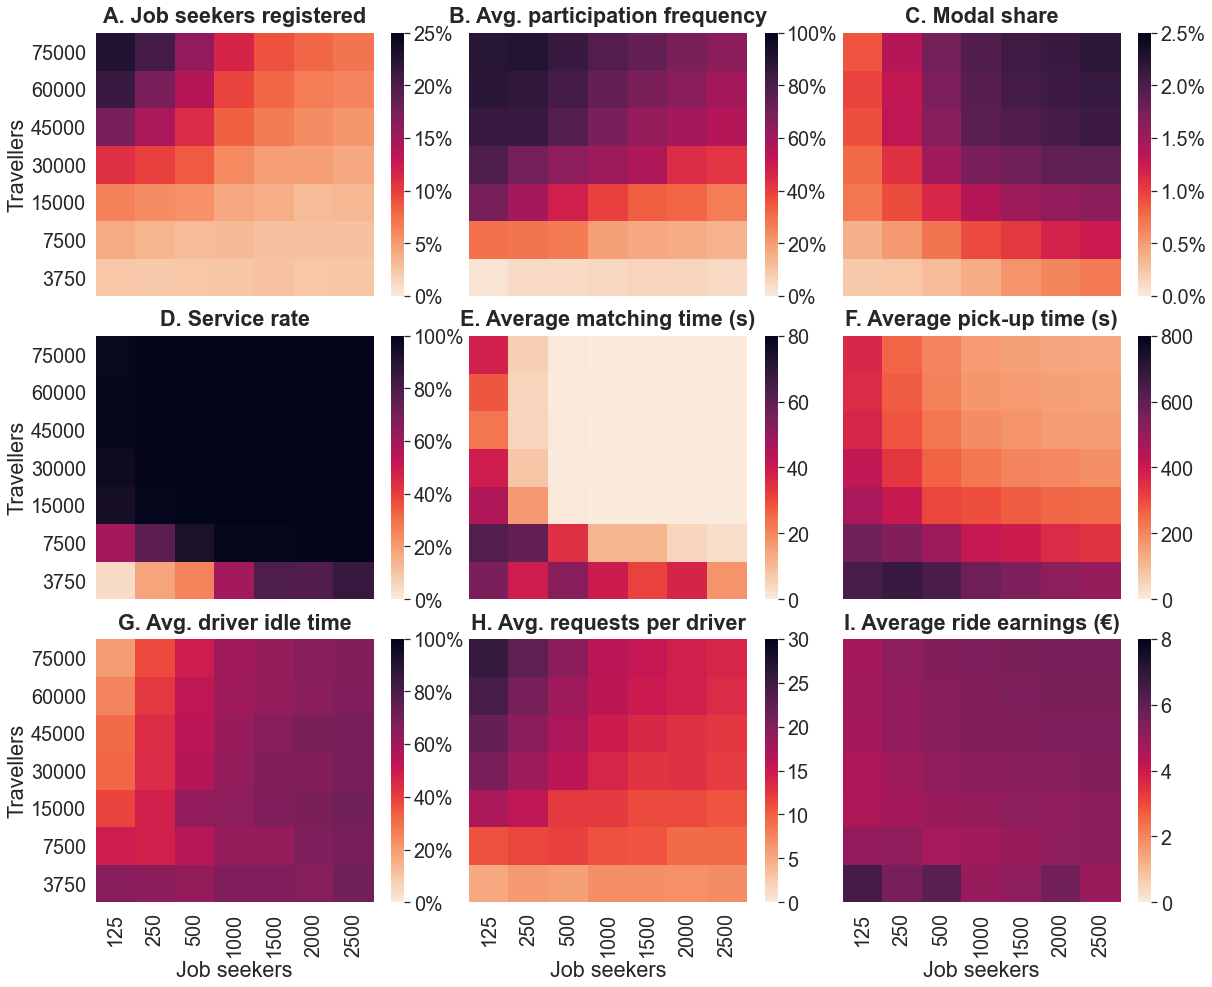

In [86]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average daily driver earnings (euro)')
# axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0.0, vmax=8.0)
axes[2,2].set_title('I. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Job seekers')
axes[2,2].set_ylabel('Travellers')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=30)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Job seekers')
axes[2,1].set_ylabel('Travellers')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Job seekers')
axes[2,0].set_ylabel('Travellers')
# axes[2,0].yaxis.label.set_visible(False)

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Average time between request and pick-up')
# axes[1,1].invert_yaxis()

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')
axes[1,0].xaxis.label.set_visible(False)
# axes[1,0].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=80)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=800)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

# res_proc['req_per_driver'] = eql_scn.sup.particip / eql_scn.dem.requests
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_per_driver'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Participating drivers per request')
# axes[2,0].invert_yaxis()
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

# from matplotlib.patches import Rectangle, Polygon, Patch
# array = np.array([[0,0],[7,0],[7,1],[2,1],[2,2],[0,2]])
# axes[1,0].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient strategy')]

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

In [72]:
# res_proc.loc[res_proc['match_rate'] < 0.95]
res_proc

,nP,nV,mode_share,earn_req_sat,serv_req_part,regist,ptcp_prob,match_rate,match_time,pickup_time
scenario,,,,,,,,,,
15000_1000,15000,1000,0.013964,5.061471,12.352858,0.042200,0.401490,0.999215,-0.249609,294.330625
15000_125,15000,125,0.007060,4.526069,17.239059,0.066133,0.696774,0.937708,45.236403,467.740127
15000_1500,15000,1500,0.015075,5.127226,11.328657,0.039520,0.336707,1.000000,-1.077436,273.886798
15000_2000,15000,2000,0.015835,5.112121,11.441233,0.031920,0.325188,1.000000,-0.318217,258.778843
15000_250,15000,250,0.009365,4.731466,15.845130,0.059200,0.591892,0.988065,16.672026,406.124010
15000_2500,15000,2500,0.016280,5.204602,10.673077,0.033552,0.272771,1.000000,-1.307681,247.716049
15000_500,15000,500,0.011496,4.967797,12.418230,0.057360,0.483961,0.999565,0.722450,308.062692
30000_1000,30000,1000,0.017209,5.216465,13.933808,0.060720,0.610013,0.999667,-1.215158,227.867154
30000_125,30000,125,0.007748,4.573330,20.769226,0.109227,0.793945,0.968643,39.255899,420.400679


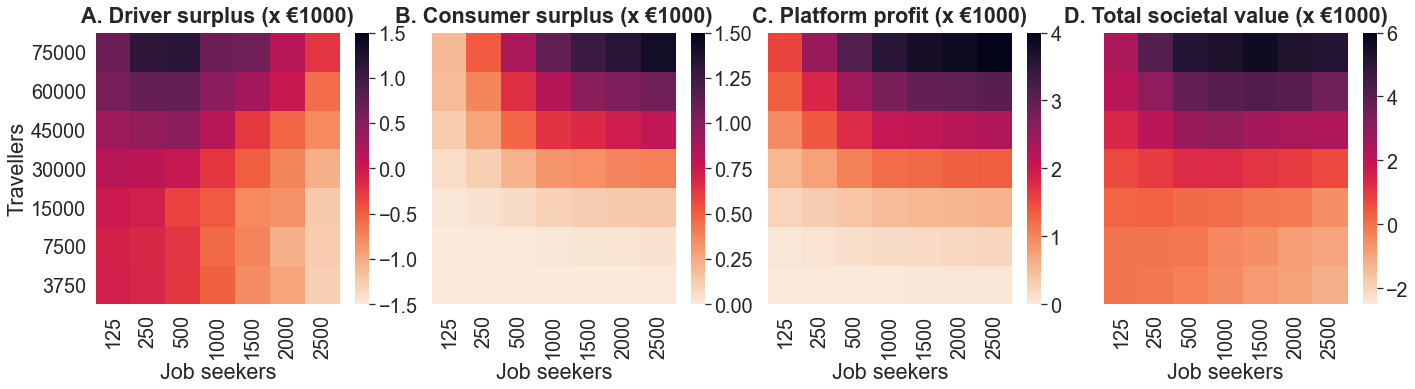

In [71]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,5],sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.1, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap, vmin=-1.5, vmax=1.5, cbar_kws={"ticks":[-1.5,-1,-0.5,0,0.5,1,1.5]})
axes[0].set_title('A. Driver surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[0].invert_yaxis()
axes[0].set_ylabel('Travellers')
axes[0].set_xlabel('Job seekers')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap, vmin=0, vmax=1.5)
axes[1].set_title('B. Consumer surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[1].invert_yaxis()
axes[1].set_ylabel('Travellers')
axes[1].set_xlabel('Job seekers')
axes[1].yaxis.label.set_visible(False)

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap, vmin=0, vmax=4)
axes[2].set_title('C. Platform profit (x \u20ac1000)',fontweight="bold", pad=10)
axes[2].invert_yaxis()
axes[2].set_ylabel('Travellers')
axes[2].set_xlabel('Job seekers')
axes[2].yaxis.label.set_visible(False)

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap, vmin=-2.5, vmax=6)
axes[3].set_title('D. Total societal value (x \u20ac1000)',fontweight="bold", pad=10)
axes[3].invert_yaxis()
axes[3].set_ylabel('Travellers')
axes[3].set_xlabel('Job seekers')
axes[3].yaxis.label.set_visible(False)

# eql_scn.sup['rel_driv_surplus'] = eql_scn.sup.driver_surplus / eql_scn.sup.nV
# eql_scn.dem['rel_cons_surplus'] = eql_scn.dem.cons_surplus / eql_scn.sup.nP

# axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_driv_surplus'), ax = axes[0], cmap=cmap)
# axes[0].set_title('Labour surplus per job seeker',fontweight="bold")
# axes[0].invert_yaxis()
# axes[0].set_xlabel('Job seekers')
# axes[0].set_ylabel('Travellers')
# # axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

# axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_cons_surplus'), ax = axes[1], cmap=cmap)
# axes[1].set_title('Consumer surplus per traveller',fontweight="bold")
# axes[1].invert_yaxis()
# axes[1].set_xlabel('Job seekers')
# axes[1].set_ylabel('Travellers')

# axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap)
# axes[2].set_title('Platform profit (x \u20ac1000)',fontweight="bold")
# axes[2].invert_yaxis()
# axes[2].set_xlabel('Job seekers')
# axes[2].set_ylabel('Travellers')

# axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap)
# axes[3].set_title('Total societal value (x \u20ac1000)',fontweight="bold")
# axes[3].invert_yaxis()
# axes[3].set_xlabel('Job seekers')
# axes[3].set_ylabel('Travellers')


# from matplotlib.patches import Rectangle
# axes[3].add_patch(Rectangle((1, 5), 5, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 4, hatch='.', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((3, 0), 3, 6, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))

# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", hatch='..', edgecolor='k',
#                          label='Pareto inefficient: increase per-kilometre fare'),
#                    Patch(facecolor="None", hatch='\\\\', edgecolor='k',
#                          label='Pareto inefficient: decrease per-kilometre fare'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k', 
#                          label='Pareto inefficient: decrease commission rate'),
#                    Patch(facecolor="None", hatch='++', edgecolor='k', 
#                          label='Pareto inefficient: increase per-kilometre fare and decrease commission'),
#                    Patch(facecolor="None", hatch='OO', edgecolor='k', 
#                          label='Pareto inefficient: decrease per-kilometre fare and commission'),
#                    Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient')]
# axes[3].legend(handles=legend_elements, loc='center')

# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 6, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 4, 6, hatch='\\\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 6, 2, hatch='--', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))


# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k',
#                          label='Per-kilometre fare too low'),
#                    Patch(facecolor="None", hatch='\\\\\\', edgecolor='k',
#                          label='Per-kilometre fare too high'),
#                    Patch(facecolor="None", hatch='---', edgecolor='k', 
#                          label='Commission rate too high')]
# axes[3].legend(handles=legend_elements,fontsize=12, loc='center', bbox_to_anchor=(0.5, -0.35))

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_soc.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

In [ ]:
eql_scn.soc.soc_value.min()
eql_scn.sup.keys()

In [ ]:
# eql_scn.dem.loc['3750_125']
eql_scn.dem['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
eql_scn.sup['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df = eql_scn.dem.pivot(index='sd-ratio', columns='nP', values='mean_wait')
df2 = eql_scn.sup.pivot(index='sd-ratio', columns='nP', values='mean_exp_inc')
# # ax = df.plot(xticks=eql_scn.dem['sd-ratio'], ylabel='mean_wait')
ax = df.plot(ylabel='wait time',marker='o',linestyle='none')
ax2 = df2.plot(ylabel='inc',marker='o',linestyle='none')
ax.set_xlim(0,0.3)
ax2.set_xlim(0,0.3)

df3 = pd.DataFrame()
df3['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df3['sd-ratio'] = eql_scn.sup.particip / eql_scn.dem.requests
ax3 = df3.plot.scatter(x='pot-sd-ratio',y='sd-ratio')
ax3.plot([0,0.2],[0,0.2])

df4 = pd.DataFrame()
df4['nP'] = eql_scn.sup.nP
df4['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df4['pickup-time'] = eql_scn.dem.pickup_time
piv_1 = df4.pivot(index='pot-sd-ratio', columns='nP',values='pickup-time')
ax4 = piv_1.plot(ylabel='pickup time', marker='o',linestyle='none')
df4['reqs'] = eql_scn.dem.requests / eql_scn.sup.nP
piv_2 = df4.pivot(index='pot-sd-ratio', columns='nP',values='reqs')
ax5 = piv_2.plot(ylabel='modal share', marker='o',linestyle='none')
# df4['ratio_ptcp_req'] = eql_scn.dem.requests / eql_scn.sup.particip
# piv_3 = df4.pivot(index='pot-sd-ratio', columns='nP',values='ratio_ptcp_req')
# ax6 = piv_3.plot(ylabel='ratio req / ptcp', marker='o',linestyle='none')
df4['match-time'] = eql_scn.dem.match_time
piv_4 = df4.pivot(index='pot-sd-ratio', columns='nP',values='match-time')
ax7 = piv_4.plot(ylabel='match time', marker='o',linestyle='none')
df4['idle_share'] = eql_scn.sup.share_idle_time
piv_5 = df4.pivot(index='pot-sd-ratio', columns='nP',values='idle_share')
ax8 = piv_5.plot(ylabel='share of time idle', marker='o',linestyle='none')
df4['ptcp_share'] = eql_scn.sup.particip / eql_scn.dem.nV
piv_6 = df4.pivot(index='pot-sd-ratio', columns='nP',values='ptcp_share')
ax9 = piv_6.plot(ylabel='share of js participating', marker='o',linestyle='none')
df4['req_earnings'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
piv_7 = df4.pivot(index='pot-sd-ratio', columns='nP',values='req_earnings')
ax10 = piv_7.plot(ylabel='avg req earnings', marker='o',linestyle='none')
df4['avg_sat_req'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
piv_8 = df4.pivot(index='pot-sd-ratio', columns='nP',values='avg_sat_req')
ax11 = piv_8.plot(ylabel='share of js participating', marker='o',linestyle='none')

df4['nV'] = eql_scn.dem.nV
# df4['rel_sup'] = eql_scn.dem.nV / eql_scn.dem.nV.max() / 10
# df5 = df4.loc[df4['nP'] == 75000]
# df5 = df5.sort_values(by='nV')
# piv_8 = df4.pivot(index='rel_sup', columns='pot-sd-ratio',values='pickup-time')
# piv_8 = piv_8.loc[:,(~piv_8.isna()).sum() >= 3]
# ax11 = piv_8.plot(ylabel='pick-up time', marker='o', linestyle='none')
# ax11.legend(['1/120','1/60','1/30','1/15', '1/7.5'])
# ax11.get_legend().remove()
# ax11 = piv_8.plot(ylabel='share of js participating', marker='o')
# ax12 = df5.plot(x='rel_market_size',y='pickup-time',label='nP=75000')
# df6 = df4.loc[df4['pot-sd-ratio'] == (1/30)].sort_values(by='rel_market_size')
# df7 = df4.loc[df4['pot-sd-ratio'] == (1/30)].sort_values(by='rel_market_size')
# ax13 = df5.plot(x='rel_market_size',y='pickup-time',label='fixed ratio')
df4['rel_dem'] = eql_scn.dem.nP / eql_scn.dem.nP.max() / 10
piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='pickup-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax12 = piv_9.plot(ylabel='pick-up time', marker='o', linestyle='none')
ax12.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='reqs')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='reqs', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='match-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='match-time', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='idle_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='idle-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='ptcp_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='ptcp-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='req_earnings')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='req-earnings', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='avg_sat_req')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='avg_sat_req', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

In [ ]:
df

In [ ]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '3750_2500'
fig = plot_multi_graph_runs(d2d.sup[scn_name], d2d.dem[scn_name])
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '60000_125'
run_ids = d2d.sup[scn_name].inform.drop(['stdev','mean'],axis=1).columns.to_list()
# run_ids = [6,0]
fig, axes = plt.subplots(2, 3, figsize = [24,24])
 # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,200])

axes[0, 0].plot(d2d.sup[scn_name].regist[run_ids])
axes[0, 0].set_ylabel('Registered driver agents', fontsize = 10)
axes[0, 0].set_xlabel('Day', fontsize = 10)
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = 0, top = d2d.sup[scn_name].regist.max().max() + 25)
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot(d2d.sup[scn_name].particip[run_ids])
axes[0, 1].set_ylabel('Participating driver agents', fontsize = 10)
axes[0, 1].set_xlabel('Day', fontsize = 10)
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = 0, top = d2d.sup[scn_name].particip.max().max())
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(d2d.sup[scn_name].mean_perc_inc[run_ids])
axes[0, 2].set_ylabel('Expected income', fontsize = 10)
axes[0, 2].set_xlabel('Day', fontsize = 10)
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = 0, top = d2d.sup[scn_name].mean_perc_inc.max().max())
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(d2d.dem[scn_name].perc_wait_req[run_ids])
axes[1, 0].set_ylabel('Expected wait time (s)', fontsize = 10)
axes[1, 0].set_xlabel('Day', fontsize = 10)
axes[1, 0].set_title('(c)')
axes[1, 0].set_ylim(bottom = 0, top = d2d.dem[scn_name].perc_wait_req.max().max())
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(d2d.dem[scn_name].requests[run_ids])
axes[1, 1].set_ylabel('Requests', fontsize = 10)
axes[1, 1].set_xlabel('Day', fontsize = 10)
axes[1, 1].set_title('(c)')
axes[1, 1].set_ylim(bottom = 0, top = d2d.dem[scn_name].requests.max().max())
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(d2d.dem[scn_name].gets_offer[run_ids])
axes[1, 2].set_ylabel('Service rate', fontsize = 10)
axes[1, 2].set_xlabel('Day', fontsize = 10)
axes[1, 2].set_title('(c)')
axes[1, 2].set_ylim(bottom = 0, top = d2d.dem[scn_name].gets_offer.max().max())
axes[1, 2].locator_params(axis='y', nbins=5)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_select.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Plot an individual indicator
plot_inform = res_scn.sup.regist.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [ ]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
# print(eql_scn.sup.astype('str').T.to_latex(index=True))
# print(eql_scn.dem.astype('str').T.to_latex(index=True))
# print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [ ]:
# Plot indicators for single scenario (e.g. base scenario)
value = '75000_125' # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [ ]:
pd.set_option('display.max_rows', 500)
micro.dem.corr_wait_time[45][['36','37']]

In [ ]:
res.dem[45].head(50)

In [ ]:
res.sup[38].head(50)

In [ ]:
# Investigating diagonal (for determination of representative sample size)
indices = [0.02,0.04,0.06,0.08,0.1,0.12,0.16,0.2,0.25]
labels = ['15000_500','30000_1000','45000_1500','60000_2000','75000_2500','90000_3000','120000_4000','150000_5000','187500_6250']

scal_sup = eql_scn.sup.loc(axis=0)[labels]
scal_sup.index = indices
scal_dem = eql_scn.dem.loc(axis=0)[labels]
scal_dem.index = indices
scal_plf = eql_scn.plf.loc(axis=0)[labels]
scal_plf.index = indices
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.plat_profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = indices, data = [5.25, 7.5, 15, 23, 28, 30, 44, 63.5, 85])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 100) 

fig.savefig(os.path.join(os.getcwd(),"plots",'sample_effect.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
kpis_dem

In [ ]:
# run_id = 0
# prefs = params[run_id]['evol']['travellers']['mode_pref']
# rs_ivt = requests[run_id].dist / params[run_id]['speeds']['ride']
# rs_fare = params[run_id]['platforms']['base_fare'] + params[run_id]['platforms']['fare'] * requests[run_id].dist / 1000
# rs_fare[rs_fare < params[run_id]['platforms']['min_fare']] = params[run_id]['platforms']['min_fare']
# beta_ivt = requests[run_id].VoT * prefs['beta_cost'] / 3600
# beta_wait = beta_ivt * prefs['wait_multip']
# U_rs = beta_ivt * rs_ivt + prefs['beta_cost'] * rs_fare + prefs['ASC_rs']
# U_wait = micro.dem.wait_time[run_id].mul(beta_wait, axis=0)
# U_wait_perc  = micro.dem.perc_wait[run_id].mul(beta_wait, axis=0)
# # U_rs = U_wait.add(U_rs, axis=0)
# U_rs = U_wait_perc.add(U_rs,axis=0)
# exp_U_rs = np.exp(U_rs)
# #         requests['U_rs'] = U_rs.copy()
# #         U_best_alt = requests[run_id][['U_pt','U_car','U_bike']].max(axis=1)
# exp_df = pd.DataFrame()
# exp_df['pt'] = np.exp(requests[run_id].U_pt)
# exp_df['car'] = np.exp(requests[run_id].U_car)
# exp_df['bike'] = np.exp(requests[run_id].U_bike)
# exp_sum_alt = exp_df.pt + exp_df.car + exp_df.bike

# exp_U_tot = exp_U_rs.add(exp_sum_alt, axis=0)
# exp_U_alts = exp_U_tot - exp_U_rs
# logsum_tot = np.log(exp_U_tot)
# logsum_alts = np.log(exp_U_alts)
# logsum_diff = logsum_tot - logsum_alts
# soc_welfare = (logsum_diff / -prefs['beta_cost']).sum(axis=0)

In [ ]:
eql_scn.soc.loc[eql_scn.soc.nP == 75000]

In [ ]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
micro.dem.perc_wait[45]

In [ ]:
requests[45]

In [ ]:
eql_scn.sup.std_exp_inc / eql_scn.sup.mean_exp_inc

In [ ]:
params[0]

In [ ]:
eql_runs.sup['75000_125']

In [ ]:
eql_runs.dem['60000_250']

In [ ]:
var_val

In [ ]:
res.sup[0].mean_perc_inc_reg

In [ ]:
kokos = DotMap()
kokos['conv_factor'] = 0.01
kokos['conv_day'] = 5
perc_values = res.sup[0].mean_perc_inc_reg
df = pd.DataFrame()
df['t'] = perc_values
df['t-1'] = df.t.shift(1)
df = df.drop([0])
df['rdiff'] = (df['t'] - df['t-1']) / df['t-1']
df['stable'] = abs(df.rdiff) < kokos['conv_factor']
df['conv_cum'] = df.stable.cumsum()
df['conv_cum_early'] = df.conv_cum.shift(kokos['conv_day'])
df['conv'] = (df.conv_cum - df.conv_cum_early == kokos['conv_day'])
if df.conv.sum() == 0:
    t_conv = params['nD']-1
    perc_conv = perc_values[t_conv]
else:
    t_conv = df.index.get_loc(df.index[df.conv == True][0])
    perc_conv = df.iloc[t_conv].t
conv_res = [t_conv, perc_conv]

In [ ]:
micro.sup.exp_inc[295][~micro.sup.exp_inc[295]['1'].isna()]

In [ ]:
micro.sup.perc_inc[295][~micro.sup.perc_inc[295]['2'].isna()]

In [ ]:
micro.sup.ptcp[295][micro.sup.ptcp[295]['2']]

In [ ]:
d2d.sup['75000_125'].inform.head(40)

In [ ]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 0)
    if one_ptcp.any():
        print('run_id {} has day with 0 participants - scenario {}'.format(i,scn.val[i]))
        a += 1
#     if res.sup[i][res.sup[i].particip == 1].shape[0] > 0:
#         print('run_id {} has one day with 1 participant'.format(i))

In [ ]:
len(res.sup)

In [ ]:
print(a)

In [ ]:
res.sup[0].mean_perc_inc.head(50)

In [ ]:
scn

In [ ]:
var_val

In [ ]:
res.sup[103].head(50)

In [ ]:
res.sup[14]

In [ ]:
eql_runs.sup['3750_2500']

In [ ]:
d2d.sup['3750_2500'].inform

In [ ]:
eql_stoch = pd.DataFrame(columns = ['ptcp', 'perc_inc', 'req', 'perc_wait'])
for item in vals:
    ind_1 = eql_runs.sup[item].particip.std() / eql_runs.sup[item].particip.mean() 
    ind_2 = eql_runs.sup[item].mean_perc_inc_reg.std() / eql_runs.sup[item].mean_perc_inc_reg.mean()
    ind_3 = eql_runs.dem[item].requests.std() / eql_runs.dem[item].requests.mean()
    ind_4 = eql_runs.dem[item].perc_wait_req.std() / eql_runs.dem[item].perc_wait_req.mean()
    series = pd.Series([ind_1,ind_2,ind_3,ind_4], index = eql_stoch.columns)
    eql_stoch = eql_stoch.append(series, ignore_index=True)
eql_stoch['scn'] = vals
eql_stoch.set_index('scn', inplace = True)
eql_stoch

In [ ]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,6])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_stoch.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['ptcp'] = eql_stoch.ptcp.copy()
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.4)
axes[0].set_title('Participation volume')
axes[0].invert_yaxis()

res_proc['perc_inc'] = eql_stoch.perc_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=0.4)
axes[1].set_title('Expected income')
axes[1].invert_yaxis()

res_proc['req'] = eql_stoch.req.copy()
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req'), ax = axes[2], cmap=cmap, vmin=0, vmax=0.4)
axes[2].set_title('Request volume')
axes[2].invert_yaxis()

res_proc['perc_wait'] = eql_stoch.perc_wait.copy()
axes[3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_wait'), ax = axes[3], cmap=cmap, vmin=0, vmax=0.4)
axes[3].set_title('Expected waiting time')
axes[3].invert_yaxis()

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], '{}-{}_market-size-stochasticity.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

In [ ]:
eql_scn.sup

In [ ]:
eql_runs.sup['15000_1000']

In [ ]:
eql_runs.dem['15000_1000']

In [ ]:
d2d.dem['3750_2500'].perc_wait.columns.tolist()

In [23]:
params[0]

{'NAME': 'default',
 'city': 'Amsterdam, Netherlands',
 'nP': 15000,
 'nV': 1000,
 'times': {'request': 15,
  'transaction': 20,
  'pickup': 30,
  'dropoff': 10,
  'patience': 600,
  'pickup_patience': 90},
 'speeds': {'walk': 1.2, 'ride': 10, 'bike': 4.0, 'pt': 5.0},
 't0': '2022-02-14 15:47:32',
 'paths': {'main': '/Users/rkucharski/Documents/GitHub/MaaSSim',
  'data': '/Users/rkucharski/Documents/GitHub/MaaSSim/data',
  'params': '/Users/rkucharski/Documents/GitHub/MaaSSim/data/configs',
  'G': 'data/graphs/Amsterdam.graphml',
  'skim': 'data/graphs/Amsterdam.csv',
  '_ipython_display_': {},
  '_repr_mimebundle_': {},
  '_repr_html_': {},
  '_repr_markdown_': {},
  '_repr_svg_': {},
  '_repr_png_': {},
  '_repr_pdf_': {},
  '_repr_jpeg_': {},
  '_repr_latex_': {},
  '_repr_json_': {},
  '_repr_javascript_': {},
  'albatross': 'data/albatross'},
 'dist_threshold': 100000,
 'big_time': 10,
 'sleep': False,
 'simTime': 8,
 'demand_structure': {'origins_dispertion': -0.0003,
  'destinat